## Install & Imports

In [1]:
!pip install -q lightning wandb kagglehub audiomentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 15.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 21.7 MB/s eta 0:00:00


In [ ]:
import os, random, warnings, glob, json
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models

import pytorch_lightning as L
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import WandbLogger

from sklearn.metrics import f1_score, accuracy_score, classification_report
import wandb
import kagglehub

warnings.filterwarnings('ignore')
print(f"PyTorch  : {torch.__version__}")
print(f"Lightning: {L.__version__}")
print(f"CUDA     : {torch.cuda.is_available()} | GPUs: {torch.cuda.device_count()}")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

PyTorch  : 2.8.0+cu126
Lightning: 2.6.1
CUDA     : True | GPUs: 2


## Config

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
L.seed_everything(SEED, workers=True)

# Paths
BASE_DIR    = Path('/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup')
STEMS_DIR   = BASE_DIR / 'genres_stems'
ESC_DIR     = BASE_DIR / 'ESC-50-master' / 'audio'
MASHUP_DIR  = BASE_DIR / 'mashups'
TEST_CSV    = BASE_DIR / 'test.csv'
OUTPUT_DIR  = Path('/kaggle/working/')

# Audio config
# Sample_rate=22050: Standard librosa default
# DURATION=10: 10s to capture genre pattern
CFG = dict(
    sr          = 22050,
    duration    = 10,
    n_mels      = 128,
    n_fft       = 2048,
    hop_length  = 512,
    img_size    = 224,

    # Training
    batch_size  = 32,
    num_workers = 4,
    val_split   = 0.15,
    max_epochs  = 30,
    lr          = 3e-4,
    weight_decay= 1e-4,
    label_smoothing = 0.1,

    # Classes
    num_classes = 10,
    genres      = ['blues','classical','country','disco','hiphop',
                   'jazz','metal','pop','reggae','rock'],

    # Augmentation probability
    aug_prob    = 0.5,

    # Noise SNR range (dB)
    snr_min     = 5,
    snr_max     = 20,

    # kagglehub
    kaggle_user = 'kaushalvaid',
    kh_dataset  = 'messy-mashup-checkpoints',

    # W&B project name
    wandb_project = '24f2000681-t12026',
)

GENRE2IDX = {g: i for i, g in enumerate(CFG['genres'])}
IDX2GENRE = {i: g for g, i in GENRE2IDX.items()}

SAMPLES = CFG['sr'] * CFG['duration']  # total number of audio samples per clip

print('Config loaded. Genres:', CFG['genres'])
print(f'Each clip = {SAMPLES:,} samples @ {CFG["sr"]} Hz = {CFG["duration"]}s')

Seed set to 42


Config loaded. Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Each clip = 220,500 samples @ 22050 Hz = 10s


## 3. Dataset & Augmentation

### Audio utility functions

> **Mel spectrogram?**  
> Converts audio --> 2D image 

Audio shape  : (220500,)
Spectrogram  : (128, 431)
Tensor shape : torch.Size([3, 224, 224])


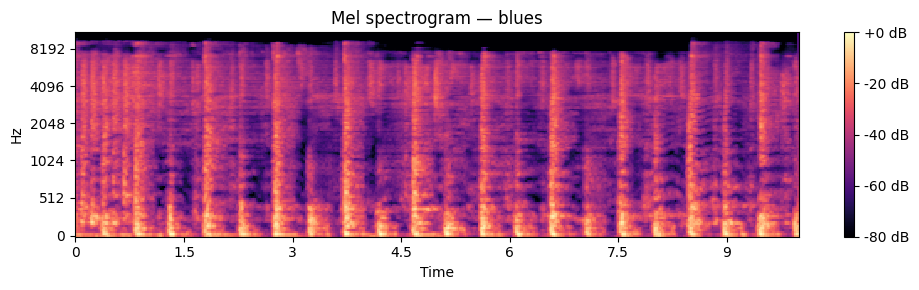

In [4]:
def load_audio(path, sr, duration):
    """
    Load a .wav file and return a fixed-length numpy array.
    """
    y, _ = librosa.load(path, sr=sr, mono=True)
    n = len(y)
    target = sr * duration

    if n < target:
        # Pad
        repeats = (target // n) + 1
        y = np.tile(y, repeats)[:target]
    else:
        # crop
        start = random.randint(0, n - target)
        y = y[start: start + target]

    return y


def audio_to_melspec(y, sr, n_mels, n_fft, hop_length):
    """
    Convert raw audio waveform --> Mel spectrogram --> dB scale --> numpy float32.
    """
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db.astype(np.float32)


def normalize_spec(spec):
    """
    Normalize spectrogram to [0, 1] per sample.
    """
    mn, mx = spec.min(), spec.max()
    if mx - mn > 1e-6:
        spec = (spec - mn) / (mx - mn)
    return spec


def spec_to_tensor(spec, img_size):
    """
    Mel spectrogram --> 3-channel tensor of shape (3, img_size, img_size).
    """
    spec = normalize_spec(spec)
    t = torch.tensor(spec).unsqueeze(0)
    t = t.repeat(3, 1, 1)
    t = F.interpolate(
        t.unsqueeze(0),
        size=(img_size, img_size),
        mode='bilinear',
        align_corners=False
    ).squeeze(0)
    return t


# sanity-check --> load one file and display
sample_genre = 'blues'
sample_path = list((STEMS_DIR / sample_genre / 'blues.00000').glob('*.wav'))[0]
y_sample = load_audio(str(sample_path), CFG['sr'], CFG['duration'])
spec_sample = audio_to_melspec(y_sample, CFG['sr'], CFG['n_mels'],
                                CFG['n_fft'], CFG['hop_length'])
print(f'Audio shape  : {y_sample.shape}')
print(f'Spectrogram  : {spec_sample.shape}')
print(f'Tensor shape : {spec_to_tensor(spec_sample, CFG["img_size"]).shape}')

plt.figure(figsize=(10, 3))
librosa.display.specshow(spec_sample, sr=CFG['sr'], hop_length=CFG['hop_length'],
                         x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel spectrogram — {sample_genre}')
plt.tight_layout()
plt.show()

### ESC-50 noise loading

In [ ]:

ESC50_FILES = sorted(ESC_DIR.glob('*.wav'))
print(f'ESC-50 noise files available: {len(ESC50_FILES)}')


def add_noise(y, sr, snr_db_min, snr_db_max):
    """
    Mix a random ESC-50 noise clip into the signal at a random SNR.
    SNR (Signal-to-Noise Ratio) in dB
    """
    noise_path = random.choice(ESC50_FILES)
    noise, _ = librosa.load(str(noise_path), sr=sr, mono=True)

    # Trim / pad noise to match signal length
    if len(noise) < len(y):
        noise = np.tile(noise, (len(y) // len(noise)) + 1)[:len(y)]
    else:
        start = random.randint(0, len(noise) - len(y))
        noise = noise[start: start + len(y)]

    # Compute RMS energies and scale noise to desired SNR
    signal_rms = np.sqrt(np.mean(y ** 2)) + 1e-9
    noise_rms  = np.sqrt(np.mean(noise ** 2)) + 1e-9
    snr_db     = random.uniform(snr_db_min, snr_db_max)
    target_noise_rms = signal_rms / (10 ** (snr_db / 20.0))
    noise = noise * (target_noise_rms / noise_rms)

    return np.clip(y + noise, -1.0, 1.0)


def time_stretch(y, sr):
    """
    Randomly speed up or slow down the audio without changing pitch.
    """
    rate = random.uniform(0.85, 1.15)
    y_stretched = librosa.effects.time_stretch(y, rate=rate)
    # Re-crop/pad back to original length after stretching changes length
    target = CFG['sr'] * CFG['duration']
    if len(y_stretched) < target:
        y_stretched = np.tile(y_stretched, (target // len(y_stretched)) + 1)[:target]
    else:
        y_stretched = y_stretched[:target]
    return y_stretched


def pitch_shift(y: np.ndarray, sr: int) -> np.ndarray:
    """
    Randomly shift the pitch by ±2 semitones.
    """
    n_steps = random.uniform(-2, 2)
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)


# Spectrogram-level augmentations
# WHY spec augmentation vs audio augmentation?
# SpecAugment (Google, 2019) masks random time/frequency bands on the
# spectrogram image. It's cheaper than audio-domain augmentation (no
# re-computing the FFT) and acts like a structured dropout for the 2D image.

class SpecAugment:
    """Randomly mask time and frequency bands on the spectrogram tensor."""
    def __init__(self, freq_mask=20, time_mask=40, num_masks=2):
        self.freq_mask = freq_mask   # max frequency bins to mask
        self.time_mask = time_mask   # max time frames to mask
        self.num_masks = num_masks   # how many masks to apply

    def __call__(self, spec: torch.Tensor) -> torch.Tensor:
        """
        spec: (C, F, T) — channels, frequency bins, time frames
        We zero out random horizontal (freq) and vertical (time) bands.
        """
        _, F, T = spec.shape
        for _ in range(self.num_masks):
            # Frequency masking
            f = random.randint(0, self.freq_mask)
            f0 = random.randint(0, F - f)
            spec[:, f0: f0 + f, :] = 0.0
            # Time masking
            t = random.randint(0, self.time_mask)
            t0 = random.randint(0, T - t)
            spec[:, :, t0: t0 + t] = 0.0
        return spec

spec_augment = SpecAugment()

ESC-50 noise files available: 2000


### 3c. Stem mixing

In [6]:
STEM_NAMES = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']


def get_song_dirs(genre: str) -> list:
    """Return all song directories for a given genre."""
    return sorted((STEMS_DIR / genre).iterdir())


def load_mixed_stems(genre: str, sr: int, duration: int) -> np.ndarray:
    """
    Build a mashup-like audio clip for a genre:
    - Pick 4 different songs (one per stem type)
    - Load one stem from each song
    - Mix them together

    This directly simulates the test distribution.
    """
    song_dirs = get_song_dirs(genre)
    # Pick 4 random (possibly overlapping) songs
    chosen_songs = random.choices(song_dirs, k=4)
    mixed = np.zeros(sr * duration, dtype=np.float32)

    for song_dir, stem_name in zip(chosen_songs, STEM_NAMES):
        stem_path = song_dir / stem_name
        if stem_path.exists():
            y_stem = load_audio(str(stem_path), sr, duration)
            mixed += y_stem

    # Normalize to prevent clipping after summing 4 stems
    mx = np.abs(mixed).max()
    if mx > 1e-6:
        mixed /= mx
    return mixed

### 3d. PyTorch Dataset

In [ ]:
class MashupDataset(Dataset):
    """
    Training dataset: generates augmented Mel spectrograms on-the-go.
    """
    def __init__(self, stems_dir: Path, genres: list, cfg: dict,
                 augment: bool = True, use_mixing: bool = True):
        self.stems_dir  = stems_dir
        self.genres     = genres
        self.cfg        = cfg
        self.augment    = augment
        self.use_mixing = use_mixing

        self.samples = []
        for genre in genres:
            for song_dir in sorted((stems_dir / genre).iterdir()):
                if song_dir.is_dir():
                    self.samples.append((genre, song_dir))

        print(f'Dataset: {len(self.samples)} songs across {len(genres)} genres')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        genre, song_dir = self.samples[idx]
        label = GENRE2IDX[genre]
        cfg   = self.cfg

        if self.use_mixing and random.random() < 0.5:
            y = load_mixed_stems(genre, cfg['sr'], cfg['duration'])
        else:
            stem_files = list(song_dir.glob('*.wav'))
            if not stem_files:
                y = np.zeros(cfg['sr'] * cfg['duration'], dtype=np.float32)
            else:
                path = random.choice(stem_files)
                y = load_audio(str(path), cfg['sr'], cfg['duration'])

        # Audio augmentations
        if self.augment:
            if random.random() < cfg['aug_prob']:
                y = add_noise(y, cfg['sr'], cfg['snr_min'], cfg['snr_max'])
            if random.random() < cfg['aug_prob'] * 0.5:   # 25% chance
                y = time_stretch(y, cfg['sr'])
            if random.random() < cfg['aug_prob'] * 0.5:   # 25% chance
                y = pitch_shift(y, cfg['sr'])

        # Convert to Mel spectrogram tensor
        spec = audio_to_melspec(y, cfg['sr'], cfg['n_mels'],
                                cfg['n_fft'], cfg['hop_length'])
        tensor = spec_to_tensor(spec, cfg['img_size'])   # (3, 224, 224)

        # Spectrogram augmentation (SpecAugment)
        if self.augment and random.random() < cfg['aug_prob']:
            tensor = spec_augment(tensor)

        return tensor, torch.tensor(label, dtype=torch.long)


class InferenceDataset(Dataset):
    """
    Test / inference dataset: loads each mashup file, returns tensor + id.
    No augmentation — we want deterministic predictions at test time.
    """
    def __init__(self, test_csv: Path, mashup_dir: Path, cfg: dict):
        self.df         = pd.read_csv(test_csv)
        self.mashup_dir = mashup_dir
        self.cfg        = cfg

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        file_id = str(row['id']).zfill(4)   # e.g. 1 → '0001'
        # Try common filename patterns
        path = self.mashup_dir / f'song{file_id}.wav'
        if not path.exists():
            path = self.mashup_dir / f'{row["id"]}.wav'

        y = load_audio(str(path), self.cfg['sr'], self.cfg['duration'])
        spec = audio_to_melspec(y, self.cfg['sr'], self.cfg['n_mels'],
                                self.cfg['n_fft'], self.cfg['hop_length'])
        tensor = spec_to_tensor(spec, self.cfg['img_size'])
        return tensor, str(row['id'])


# Build full dataset and split into train / val
full_dataset = MashupDataset(STEMS_DIR, CFG['genres'], CFG,
                              augment=True, use_mixing=True)

n_val   = int(len(full_dataset) * CFG['val_split'])
n_train = len(full_dataset) - n_val

train_ds, val_ds = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

# Disabling augmentation for validation
val_ds.dataset.augment = False

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)

print(f'Train samples: {n_train} | Val samples: {n_val}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

# Quick tensor shape check
x_batch, y_batch = next(iter(train_loader))
print(f'Batch tensor: {x_batch.shape}   Labels: {y_batch.shape}')

Dataset: 1000 songs across 10 genres
Train samples: 850 | Val samples: 150
Train batches: 27 | Val batches: 5
Batch tensor: torch.Size([32, 3, 224, 224])   Labels: torch.Size([32])


## 4. Model Definitions

### 4a. Model 1 — Custom CNN (from scratch)

> **Architecture:** 4 convolutional blocks → GlobalAveragePooling → classifier  
> Each block: `Conv2d → BatchNorm2d → ReLU → Conv2d → BatchNorm2d → ReLU → MaxPool2d` \
> and 4 blocks architecture \
> then a global avg pool \
> and finally a FC layer \

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, pool: bool = True):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2))  # halves spatial dims
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CustomCNN(nn.Module):
    def __init__(self, num_classes: int = 10, dropout: float = 0.5):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(3,   32),
            ConvBlock(32,  64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.gap(x)
        x = self.head(x)
        return x  # raw logits (CrossEntropy loss expects logits, not softmax)


# Quick parameter count
_m = CustomCNN(CFG['num_classes'])
_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'CustomCNN parameters: {_params:,}')
del _m

CustomCNN parameters: 1,207,402


### 4b. Model 2 — ResNet50 (fine-tuning)

> **WHY fine-tune instead of training from scratch?**  
> ResNet50 was pretrained on 1.28 million ImageNet images. Its lower layers already know how to detect edges, textures, and shapes. We will use that power. We only need to teach the top layers what *genre* patterns look like.

> **WHY freeze and then unfreeze (two-phase training)?**  
> Phase 1: Freeze the backbone, only train the new classifier head. This prevents the pretrained weights from being immediately destroyed by a large gradient from a randomly-initialized head.  
> Phase 2: Unfreeze everything and fine-tune with a low LR. The backbone adapts slowly to audio spectrograms.

In [ ]:
class ResNet50Classifier(nn.Module):
    """
    ResNet50 backbone with a custom classification head.
    """
    def __init__(self, num_classes: int = 10, dropout: float = 0.4,
                 freeze_backbone: bool = True):
        super().__init__()
        # Load pretrained ResNet50
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

        # Remove the original fully-connected head
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

        # New classifier head
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, num_classes),
        )

        if freeze_backbone:
            self.freeze_backbone()

    def freeze_backbone(self):
        """Freeze all backbone parameters — only head trains."""
        for param in self.backbone.parameters():
            param.requires_grad = False
        print('ResNet50: backbone FROZEN')

    def unfreeze_backbone(self):
        """Unfreeze backbone for full fine-tuning with low LR."""
        for param in self.backbone.parameters():
            param.requires_grad = True
        print('ResNet50: backbone UNFROZEN — full fine-tuning active')

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


_m = ResNet50Classifier(CFG['num_classes'])
_params_total    = sum(p.numel() for p in _m.parameters())
_params_trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'ResNet50 total params     : {_params_total:,}')
print(f'ResNet50 trainable (frozen): {_params_trainable:,} (head only)')
del _m

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 225MB/s]


ResNet50: backbone FROZEN
ResNet50 total params     : 24,562,250
ResNet50 trainable (frozen): 1,054,218 (head only)


## PyTorch Lightning Module

In [ ]:
class GenreClassifier(L.LightningModule):
    
    def __init__(self, model: nn.Module, cfg: dict, model_name: str = 'model'):
        super().__init__()
        self.model      = model
        self.cfg        = cfg
        self.model_name = model_name

        self.criterion = nn.CrossEntropyLoss(
            label_smoothing=cfg['label_smoothing']
        )

    
        self.val_preds  = []
        self.val_labels = []

        
        self.save_hyperparameters(ignore=['model'])

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        
        x, y   = batch
        logits = self(x)
        loss   = self.criterion(logits, y)
        preds  = logits.argmax(dim=1)
        acc    = (preds == y).float().mean()

        
        self.log('train/loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train/acc',  acc,  on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        
        x, y   = batch
        logits = self(x)
        loss   = self.criterion(logits, y)
        preds  = logits.argmax(dim=1)

        self.val_preds.extend(preds.cpu().numpy())
        self.val_labels.extend(y.cpu().numpy())

        self.log('val/loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        
        if not self.val_preds:
            return
        f1  = f1_score(self.val_labels, self.val_preds, average='macro', zero_division=0)
        acc = accuracy_score(self.val_labels, self.val_preds)

        self.log('val/f1_macro', f1,  prog_bar=True)
        self.log('val/acc',      acc, prog_bar=True)

        # Clear for next epoch
        self.val_preds  = []
        self.val_labels = []

    def configure_optimizers(self):
        
        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, self.model.parameters()),
            lr=self.cfg['lr'],
            weight_decay=self.cfg['weight_decay']
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=self.cfg['max_epochs'],
            eta_min=1e-6
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {'scheduler': scheduler, 'interval': 'epoch'}
        }

## Dry Run Loop


In [ ]:
DRY_RUN = False  # ← Set to False when you're ready for full training

def make_dry_loaders(cfg):
    
    from torch.utils.data import Subset
    n = cfg['batch_size'] * 2
    tr = Subset(train_ds, list(range(n)))
    vl = Subset(val_ds,   list(range(n)))
    tl = DataLoader(tr, batch_size=cfg['batch_size'], shuffle=True)
    vl = DataLoader(vl, batch_size=cfg['batch_size'], shuffle=False)
    return tl, vl


def dry_run_model(model, model_name, cfg):
    print(f'\n{'='*60}')
    print(f' DRY RUN: {model_name}')
    print(f'{'='*60}')
    tl, vl = make_dry_loaders(cfg)
    lit = GenreClassifier(model, cfg, model_name=model_name)
    trainer = L.Trainer(
        max_epochs=1,
        limit_train_batches=2,
        limit_val_batches=2,
        enable_checkpointing=False,
        logger=False,
        enable_progress_bar=True,
        accelerator='auto',
        devices=1,
    )
    trainer.fit(lit, tl, vl)
    print(f'✓ {model_name} dry run passed')


if DRY_RUN:
    dry_run_model(CustomCNN(CFG['num_classes']),
                  'CustomCNN', CFG)
    dry_run_model(ResNet50Classifier(CFG['num_classes']),
                  'ResNet50', CFG)
    print('Both dry runs passed. Set DRY_RUN = False to start full training.')
else:
    print('DRY_RUN = False — skip to full training below.')

DRY_RUN = False — skip to full training below.


## Full Training

In [13]:
# ── W&B login ────────────────────────────────────────────────────────────────
# Add your W&B API key to Kaggle Secrets (Add-ons → Secrets) as WANDB_API_KEY
# from kaggle_secrets import UserSecretsClient
# secrets = UserSecretsClient()
# wandb.login()
# print('W&B login successful')

In [ ]:
def get_callbacks(model_name: str, monitor: str = 'val/f1_macro'):
    
    ckpt = ModelCheckpoint(
        dirpath=OUTPUT_DIR / 'checkpoints',
        filename=f'{model_name}_best',
        monitor=monitor,
        mode='max',
        save_top_k=1,
        verbose=True,
    )
    early_stop = EarlyStopping(
        monitor=monitor,
        mode='max',
        patience=7,
        verbose=True,
    )
    return [ckpt, early_stop]


def train_model(model, model_name, cfg,
                train_loader, val_loader,
                phase2_unfreeze=False):
    
    print(f'\n{'='*60}')
    print(f' TRAINING: {model_name}')
    print(f'{'='*60}')

    # wandb_logger = WandbLogger(
    #     project=cfg['wandb_project'],
    #     name=model_name,
    #     log_model=False,
    # )
    # wandb_logger.experiment.config.update(cfg)

    callbacks = get_callbacks(model_name)
    lit_model = GenreClassifier(model, cfg, model_name=model_name)

    trainer = L.Trainer(
        max_epochs=cfg['max_epochs'],
        accelerator='gpu',
        devices=1,
        # strategy='ddp_notebook',  # DDP for multi-GPU
        precision='16-mixed',
        callbacks=callbacks,
        # logger=wandb_logger,
        log_every_n_steps=10,
        enable_progress_bar=True,
        deterministic=False,
    )

    #Phase 1: Train with frozen backbone
    trainer.fit(lit_model, train_loader, val_loader)

    # Phase 2: Unfreeze and fine-tune
    if phase2_unfreeze and hasattr(model, 'unfreeze_backbone'):
        print(f'\n--- Phase 2: unfreezing backbone for {model_name} ---')
        model.unfreeze_backbone()

        # Lower LR for phase 2 --> to not destroy pretrained feats
        cfg_phase2 = dict(cfg)
        cfg_phase2['lr'] = 1e-5
        cfg_phase2['max_epochs'] = 20

        lit_model2 = GenreClassifier(model, cfg_phase2, model_name=f'{model_name}_phase2')
        callbacks2 = get_callbacks(f'{model_name}_phase2')

        # wandb_logger2 = WandbLogger(
        #     project=cfg['wandb_project'],
        #     name=f'{model_name}_phase2',
        #     log_model=False,
        # )
        trainer2 = L.Trainer(
            max_epochs=cfg_phase2['max_epochs'],
            accelerator='gpu',
            devices=1,
            # strategy='ddp_notebook',
            precision='16-mixed',
            callbacks=callbacks2,
            # logger=wandb_logger2,
            log_every_n_steps=10,
            enable_progress_bar=True,
        )
        trainer2.fit(lit_model2, train_loader, val_loader)
        # wandb.finish()
        return lit_model2

    # wandb.finish()
    return lit_model

In [ ]:
if not DRY_RUN:
    # Custom CNN
    # model1 = CustomCNN(CFG['num_classes'])
    # lit1   = train_model(model1, 'CustomCNN',
    #                      CFG, train_loader, val_loader,
    #                      phase2_unfreeze=False)

    # ResNet50
    model2 = ResNet50Classifier(CFG['num_classes'], freeze_backbone=True)
    lit2   = train_model(model2, 'ResNet50',
                         CFG, train_loader, val_loader,
                         phase2_unfreeze=True)


    print('Model trained successfully')
else:
    print('DRY_RUN = True — full training skipped.')

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


ResNet50: backbone FROZEN

 TRAINING: ResNet50


2026-03-25 13:25:14.763046: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774445114.917840      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774445114.960839      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774445115.330863      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774445115.330889      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774445115.330892      55 computation_placer.cc:177] computation placer alr

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet50Classifier │ 24.6 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 1.1 M                                                                                            
Non-trainable params: 23.5 M                                                                                       
Total params: 24.6 M                                                                                               
Total estimated model params size (MB): 98                                                                         
Modules in train mode: 159                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet50Classifier │ 24.6 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 24.6 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.6 M                                                                                               
Total estimated model params size (MB): 98                                                                         
Modules in train mode: 159                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val/f1_macro improved. New best score: 0.530
Epoch 0, global step 27: 'val/f1_macro' reached 0.53013 (best 0.53013), saving model to '/kaggle/working/checkpoints/ResNet50_phase2_best.ckpt' as top 1
Metric val/f1_macro improved by 0.020 >= min_delta = 0.0. New best score: 0.550
Epoch 1, global step 54: 'val/f1_macro' reached 0.55036 (best 0.55036), saving model to '/kaggle/working/checkpoints/ResNet50_phase2_best.ckpt' as top 1
Metric val/f1_macro improved by 0.035 >= min_delta = 0.0. New best score: 0.585
Epoch 2, global step 81: 'val/f1_macro' reached 0.58488 (best 0.58488), saving model to '/kaggle/working/checkpoints/ResNet50_phase2_best.ckpt' as top 1
Epoch 3, global step 108: 'val/f1_macro' was not in top 1
Epoch 4, global step 135: 'val/f1_macro' was not in top 1
Metric val/f1_macro improved by 0.003 >= min_delta = 0.0. New best score: 0.588
Epoch 5, global step 162: 'val/f1_macro' reached 0.58833 (best 0.58833), saving model to '/kaggle/working/checkpoints/ResNet50_phase2


✅ All 3 models trained!


## kagglehub Upload

In [ ]:
# if not DRY_RUN:
#     import shutil

#     # Gather all checkpoint files
#     ckpt_dir  = OUTPUT_DIR / 'checkpoints'
#     ckpt_files = list(ckpt_dir.glob('*.ckpt'))
#     print(f'Checkpoints to upload: {[f.name for f in ckpt_files]}')

#     # Also save config so we know exact settings used
#     config_path = ckpt_dir / 'config.json'
#     with open(config_path, 'w') as f:
#         json.dump(CFG, f, indent=2)

#     # Upload to kagglehub
#     # kagglehub.dataset_upload() pushes all files in a local directory
#     # to a Kaggle dataset identified by 'username/dataset-name'
#     handle = kagglehub.dataset_upload(
#         handle   = f"{CFG['kaggle_user']}/{CFG['kh_dataset']}",
#         local_dataset_dir = str(ckpt_dir),
#         version_notes = 'Trained: CustomCNN, ResNet50, EfficientNet-B0'
#     )
#     print(f'\nUploaded to kagglehub: {handle}')
#     print('Go to kaggle.com/datasets to confirm the upload.')
# else:
#     print('DRY_RUN = True — upload skipped.')

In [ ]:
if not DRY_RUN:
    import shutil

    # Gather all checkpoint files
    ckpt_dir  = OUTPUT_DIR / 'checkpoints'
    ckpt_files = list(ckpt_dir.glob('*.ckpt'))
    print(f'Checkpoints to upload: {[f.name for f in ckpt_files]}')

    # Also save config so we know exact settings used
    config_path = ckpt_dir / 'config.json'
    with open(config_path, 'w') as f:
        json.dump(CFG, f, indent=2)

    # Upload to kagglehub
    handle = kagglehub.dataset_upload(
        handle    = f"{CFG['kaggle_user']}/{CFG['kh_dataset']}",
        local_dataset_dir = str(ckpt_dir),
        version_notes = 'Trained: ResNet50 only'
    )
    print(f'\nUploaded to kagglehub: {handle}')
    print('Go to kaggle.com/datasets to confirm the upload.')
else:
    print('DRY_RUN = True — upload skipped.')

Checkpoints to upload: ['ResNet50_best.ckpt', 'ResNet50_phase2_best.ckpt']
Uploading Dataset https://api.kaggle.com/datasets/kaushalvaid/messy-mashup-checkpoints ...
Starting upload for file /kaggle/working/checkpoints/config.json

Uploading: 100%|██████████| 599/599 [00:00<00:00, 778B/s]

Upload successful: /kaggle/working/checkpoints/config.json (599B)
Starting upload for file /kaggle/working/checkpoints/ResNet50_best.ckpt



Uploading: 100%|██████████| 107M/107M [00:07<00:00, 13.5MB/s] 

Upload successful: /kaggle/working/checkpoints/ResNet50_best.ckpt (102MB)
Starting upload for file /kaggle/working/checkpoints/ResNet50_phase2_best.ckpt



Uploading: 100%|██████████| 295M/295M [00:14<00:00, 20.8MB/s] 

Upload successful: /kaggle/working/checkpoints/ResNet50_phase2_best.ckpt (282MB)


Your dataset has been created.
Files are being processed...
See at: https://api.kaggle.com/datasets/kaushalvaid/messy-mashup-checkpoints

✅ Uploaded to kagglehub: None
Go to kaggle.com/datasets to confirm the upload.


## Inference

In [ ]:
# Download checkpoints from kagglehub
print('Downloading checkpoints from kagglehub...')
ckpt_download_path = kagglehub.dataset_download(
    f"{CFG['kaggle_user']}/{CFG['kh_dataset']}"
)
ckpt_download_path = Path(ckpt_download_path)
print(f'Downloaded to: {ckpt_download_path}')
print('Files:', [f.name for f in ckpt_download_path.iterdir()])

Mounting files to /kaggle/input/datasets/kaushalvaid/messy-mashup-checkpoints...
Downloaded to: /kaggle/input/datasets/kaushalvaid/messy-mashup-checkpoints
Files: ['config.json', 'ResNet50_phase2_best.ckpt', 'ResNet50_best.ckpt']


In [ ]:
def load_model_from_ckpt(model_class, ckpt_path: Path, cfg: dict,
                          freeze_backbone: bool = False) -> nn.Module:
    """
    Rebuild the model architecture, load weights from checkpoint.
    freeze_backbone=False: at inference time everything should be active.
    """
    if model_class in (ResNet50Classifier):
        model = model_class(cfg['num_classes'], freeze_backbone=False)
    else:
        model = model_class(cfg['num_classes'])

    lit = GenreClassifier.load_from_checkpoint(
        checkpoint_path = str(ckpt_path),
        model = model,
        cfg   = cfg,
        strict = True,
    )
    lit.eval()   # disables Dropout and BatchNorm training mode
    return lit


# Find the best checkpoint files
def find_ckpt(name_pattern: str) -> Path:
    matches = list(ckpt_download_path.glob(f'*{name_pattern}*.ckpt'))
    if not matches:
        # fallback: look for phase2 checkpoint
        matches = list(ckpt_download_path.glob(f'*{name_pattern}*phase2*.ckpt'))
    assert matches, f'No checkpoint found for pattern: {name_pattern}'
    # If phase2 exists, prefer it
    phase2 = [m for m in matches if 'phase2' in m.name]
    return phase2[0] if phase2 else matches[0]


# ckpt1 = find_ckpt('CustomCNN')
# ckpt2 = find_ckpt('ResNet50')
# print(f'Model 1 checkpoint: {ckpt1.name}')
# print(f'Model 2 checkpoint: {ckpt2.name}')


# find the ResNet50 checkpoint
ckpt_resnet = find_ckpt('ResNet50')
print(f'Model checkpoint: {ckpt_resnet.name}')

# ── Load model ───────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Inference device: {DEVICE}')

# Load just the one model
lit_model = load_model_from_ckpt(ResNet50Classifier, ckpt_resnet, CFG).to(DEVICE)

print('ResNet50 loaded and ready for inference.')

Model checkpoint: ResNet50_phase2_best.ckpt
Inference device: cuda
ResNet50 loaded and ready for inference.


In [ ]:
# Standard Inference

@torch.no_grad()
def predict_single_model(model, loader):
    """
    Run standard inference for a single model.
    """
    all_ids   = []
    all_probs = []

    for x_batch, ids in tqdm(loader, desc='Inferencing'):
        x_batch = x_batch.to(DEVICE)
        all_ids.extend(ids)
        
        # Get logits and convert to probabilities
        logits = model(x_batch)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.extend(probs)

    all_probs = np.array(all_probs)
    pred_indices  = all_probs.argmax(axis=1)
    pred_genres   = [IDX2GENRE[i] for i in pred_indices]

    return all_ids, pred_genres, all_probs

# Build inference loader 
inf_ds     = InferenceDataset(TEST_CSV, MASHUP_DIR, CFG)
inf_loader = DataLoader(inf_ds, batch_size=CFG['batch_size'],
                        shuffle=False, num_workers=CFG['num_workers'])

all_ids, pred_genres, raw_probs = predict_single_model(lit_model, inf_loader)

print(f'\nInference complete. Total predictions: {len(all_ids)}')
print('Sample predictions (first 5):')
for i in range(5):
    conf = raw_probs[i].max() * 100
    print(f'  ID={all_ids[i]} → {pred_genres[i]} (confidence: {conf:.1f}%)')

Inferencing:   0%|          | 0/95 [00:00<?, ?it/s]


Inference complete. Total predictions: 3020
Sample predictions (first 5):
  ID=1 → hiphop (confidence: 52.6%)
  ID=2 → metal (confidence: 61.1%)
  ID=3 → disco (confidence: 19.8%)
  ID=4 → metal (confidence: 86.6%)
  ID=5 → blues (confidence: 19.6%)


In [ ]:
# Write submission.csv
submission = pd.DataFrame({'id': all_ids, 'genre': pred_genres})

# Validate: all predicted genres must be in the allowed set
assert set(submission['genre']).issubset(set(CFG['genres'])), \
    f"Invalid genres found: {set(submission['genre']) - set(CFG['genres'])}"

# Validate: id count matches test.csv
test_df = pd.read_csv(TEST_CSV)
assert len(submission) == len(test_df), \
    f"Row count mismatch: got {len(submission)}, expected {len(test_df)}"

sub_path = OUTPUT_DIR / 'submission.csv'
submission.to_csv(sub_path, index=False)
print(f'\n✅ submission.csv saved to {sub_path}')
print(f'Shape: {submission.shape}')
print('\nGenre distribution in predictions:')
print(submission['genre'].value_counts().to_string())

# Preview
submission.head(10)


✅ submission.csv saved to /kaggle/working/submission.csv
Shape: (3020, 2)

Genre distribution in predictions:
genre
metal        757
jazz         392
hiphop       346
blues        281
rock         272
country      236
pop          230
disco        190
classical    166
reggae       150


,id,genre
0,1,hiphop
1,2,metal
2,3,disco
3,4,metal
4,5,blues
5,6,metal
6,7,metal
7,8,pop
8,9,hiphop
9,10,disco
